# QAOA-GPT inference demo

In [39]:
import pandas as pd
import networkx as nx
import random
from tqdm import tqdm

from src.model_interface import QAOA_GPT
from src.adapt_utils import compute_metrics 

import matplotlib.pyplot as plt

from src.utils import (
    maxcut_bruteforce,
    edgelist_to_nx,
)


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)


## Loading a model

In [40]:
qaoa_gpt = QAOA_GPT(
    model_ckpt='nanoGPT/out-10_nodes_feather/gpt_ckpt_3500_feather_ar_0_96305__er_0_0.pt',
    data_dir='nanoGPT/data/10_nodes_feather', # to take meta.pkl file 
)


Model type: gpt
Pool type: qaoa_double_pool
Embedding method: feather
Number of nodes: 10
Initiating nanoGPT model with padding support
number of parameters: 11.68M


In [41]:
# qaoa_gpt = QAOA_GPT(
#     model_ckpt='nanoGPT/models/n10w_qaoa_mixer/ckpt_16000_gemb__ar_0_96584__er_0_0.pt',
#     data_dir='nanoGPT/models/n10w_qaoa_mixer/data', # to take meta.pkl file 
# )

## Generating random graphs

In [42]:
def add_weights_to_nx_graph(nx_graph):
    for u, v in nx_graph.edges():
        cur_weight = round(random.uniform(0, 1), 2)
        while cur_weight == 0:
            cur_weight = round(random.uniform(0, 1), 2)
        nx_graph[u][v]['weight'] = cur_weight
    return nx_graph

In [43]:
tqdm.pandas()

Modify this nodes here to match the model before run

In [44]:
n_graphs = 5
n_nodes = 10

In [45]:
graphs_edgelist_list_dict = dict()

er_graphs_edgelist_list_dict = dict()
for i in range(n_graphs):
    p = random.randrange(6,9) / 10
    cur_graph = nx.erdos_renyi_graph(
        n=n_nodes,
        p=p
    )
    
    er_graphs_edgelist_list_dict[f'er_graph_{i}'] = add_weights_to_nx_graph(cur_graph)

graphs_edgelist_list_dict.update(er_graphs_edgelist_list_dict)

In [46]:
graphs_edgelist_list_dict['er_graph_2'].edges(data=True)

EdgeDataView([(0, 3, {'weight': 0.61}), (0, 4, {'weight': 0.59}), (0, 5, {'weight': 0.69}), (0, 7, {'weight': 0.58}), (0, 8, {'weight': 0.09}), (0, 9, {'weight': 0.37}), (1, 2, {'weight': 0.16}), (1, 3, {'weight': 0.72}), (1, 4, {'weight': 0.76}), (1, 5, {'weight': 0.59}), (1, 7, {'weight': 0.09}), (1, 9, {'weight': 0.53}), (2, 6, {'weight': 0.69}), (2, 8, {'weight': 0.17}), (2, 9, {'weight': 0.55}), (3, 5, {'weight': 0.13}), (3, 6, {'weight': 0.27}), (3, 7, {'weight': 0.87}), (3, 8, {'weight': 0.45}), (3, 9, {'weight': 0.4}), (4, 5, {'weight': 0.36}), (4, 7, {'weight': 0.54}), (4, 8, {'weight': 0.43}), (4, 9, {'weight': 0.58}), (5, 7, {'weight': 0.49}), (6, 7, {'weight': 0.88}), (6, 8, {'weight': 0.33}), (6, 9, {'weight': 0.24}), (7, 8, {'weight': 0.27}), (7, 9, {'weight': 0.7}), (8, 9, {'weight': 0.43})])

## Generate circuits with QAOA-GPT model

In [47]:
embedding_method = qaoa_gpt.embedding_method
print(f"Using embedding method: {embedding_method}")

qaoa_gpt_circ_df = qaoa_gpt.generate_circ_from_nx(
    graphs_edgelist_list_dict,
    # calculate_classic_maxcut=True, # to create col enery_gurobi. Default:True
    n_samples_per_batch=50, # max number of distinct graphs in a batch
    num_samples=5, # number of samples to draw
    max_new_tokens=150, # number of tokens generated in each sample
    temperature=0.1, # 1.0 = no change, < 1.0 = less random, > 1.0 = more random, in predictions
    top_k=200, # retain only the top_k most likely tokens, clamp others to have 0 probability
)

Using embedding method: feather


Preparing graphs...: 100%|██████████| 5/5 [00:00<00:00, 178.42it/s]


Performing feather embedding


100%|██████████| 5/5 [00:00<00:00, 1117.53it/s]
Inference. Current batch: n_edges: 32, n_graphs: 1: 100%|██████████| 4/4 [00:04<00:00,  1.14s/it]


In [48]:
sample_gr = graphs_edgelist_list_dict['er_graph_0'].edges(data=True)
sample_gr

EdgeDataView([(0, 1, {'weight': 0.79}), (0, 2, {'weight': 0.34}), (0, 3, {'weight': 0.78}), (0, 4, {'weight': 1.0}), (0, 6, {'weight': 0.09}), (0, 7, {'weight': 0.49}), (0, 8, {'weight': 0.5}), (0, 9, {'weight': 0.79}), (1, 2, {'weight': 0.94}), (1, 3, {'weight': 0.46}), (1, 5, {'weight': 0.57}), (1, 6, {'weight': 0.02}), (1, 7, {'weight': 0.78}), (1, 8, {'weight': 0.64}), (1, 9, {'weight': 0.93}), (2, 3, {'weight': 0.49}), (2, 4, {'weight': 0.64}), (2, 5, {'weight': 0.48}), (2, 6, {'weight': 0.05}), (2, 8, {'weight': 0.45}), (3, 4, {'weight': 0.67}), (3, 5, {'weight': 0.07}), (3, 6, {'weight': 0.08}), (3, 7, {'weight': 0.23}), (3, 8, {'weight': 0.39}), (3, 9, {'weight': 0.9}), (4, 5, {'weight': 0.49}), (4, 6, {'weight': 0.44}), (5, 6, {'weight': 0.82}), (5, 7, {'weight': 0.72}), (5, 8, {'weight': 0.18}), (5, 9, {'weight': 0.89}), (6, 9, {'weight': 0.3}), (7, 8, {'weight': 0.97}), (8, 9, {'weight': 0.04})])

In [49]:
len(graphs_edgelist_list_dict['er_graph_0'].edges(data=True))

35

The graph after prediction is shifted by 1 unit. For example, in NetworkX the edge is (0, 2, 0.36), but in this DataFrame it becomes (1, 3, 0.36)

In [50]:
qaoa_gpt_circ_df[:1]

,graph,n_edges,q_circuits,adapt_circuit,adapt_full_ar,graph_prefix,energy_gurobi,label,graph_w_jl,graph_weight_norm,took_time
0,"[(1, 4), 0.61, (1, 5), 0.59, (1, 6), 0.69, (1, 8), 0.58, (1, 9), 0.09, (1, 10), 0.37, (2, 3), 0.16, (2, 4), 0.72, (2, 5), 0.76, (2, 6), 0.59, (2, 8), 0.09, (2, 10), 0.53, (3, 7), 0.69, (3, 9), 0.17, (3, 10), 0.55, (4, 6), 0.13, (4, 7), 0.27, (4, 8), 0.87, (4, 9), 0.45, (4, 10), 0.4, (5, 6), 0.36, (5, 8), 0.54, (5, 9), 0.43, (5, 10), 0.58, (6, 8), 0.49, (7, 8), 0.88, (7, 9), 0.33, (7, 10), 0.24, (8, 9), 0.27, (8, 10), 0.7, (9, 10), 0.43]",31,"[[new_layer_p, 11.0, -2.08, 0.34, new_layer_p, 11.0, -0.36, 0.67, new_layer_p, 11.0, -0.3, 0.74, new_layer_p, 11.0, -0.27, 0.85, new_layer_p, 11.0, -0.25, 0.95, new_layer_p, 11.0, -0.22, 1.02, new_layer_p, 11.0, -0.19, 1.1, new_layer_p, 11.0, -0.14, 1.2, new_layer_p, 11.0, -0.09, 1.4], [new_layer_p, 11.0, -2.08, 0.34, new_layer_p, 11.0, -0.36, 0.67, new_layer_p, 11.0, -0.3, 0.77, new_layer_p, 11.0, -0.27, 0.84, new_layer_p, 11.0, -0.25, 0.92, new_layer_p, 11.0, -0.22, 0.99, new_layer_p, 11.0, -0.19, 1.1, new_layer_p, 11.0, -0.17, 1.18, new_layer_p, 11.0, -0.09, 1.27], [new_layer_p, 11.0, -0.5, 0.34, new_layer_p, 11.0, -0.36, 0.69, new_layer_p, 11.0, -0.3, 0.77, new_layer_p, 11.0, -0.26, 0.85, new_layer_p, 11.0, -0.23, 0.92, new_layer_p, 11.0, -0.2, 0.92, new_layer_p, 11.0, -0.17, 1.02, new_layer_p, 11.0, -0.09, 1.23], [new_layer_p, 11.0, -0.53, 0.35, new_layer_p, 11.0, -0.39, 0.7, new_layer_p, 11.0, -0.34, 0.77, new_layer_p, 11.0, -0.3, 0.82, new_layer_p, 11.0, -0.26, 0.92, new_layer_p, 11.0, -0.22, 0.99, new_layer_p, 11.0, -0.19, 1.1, new_layer_p, 11.0, -0.1, 1.27], [new_layer_p, 11.0, -2.08, 0.34, new_layer_p, 11.0, -0.36, 0.67, new_layer_p, 11.0, -0.3, 0.77, new_layer_p, 11.0, -0.26, 0.85, new_layer_p, 11.0, -0.23, 0.92, new_layer_p, 11.0, -0.22, 1.0, new_layer_p, 11.0, -0.19, 1.02, new_layer_p, 11.0, -0.17, 1.17, new_layer_p, 11.0, -0.09, 1.31]]",[],None,er_graph_2,-11.22,test_interactive,"[[1, 4, 0.61], [1, 5, 0.59], [1, 6, 0.69], [1, 8, 0.58], [1, 9, 0.09], [1, 10, 0.37], [2, 3, 0.16], [2, 4, 0.72], [2, 5, 0.76], [2, 6, 0.59], [2, 8, 0.09], [2, 10, 0.53], [3, 7, 0.69], [3, 9, 0.17], [3, 10, 0.55], [4, 6, 0.13], [4, 7, 0.27], [4, 8, 0.87], [4, 9, 0.45], [4, 10, 0.4], [5, 6, 0.36], [5, 8, 0.54], [5, 9, 0.43], [5, 10, 0.58], [6, 8, 0.49], [7, 8, 0.88], [7, 9, 0.33], [7, 10, 0.24], [8, 9, 0.27], [8, 10, 0.7], [9, 10, 0.43]]",1.0,4.591359


In [51]:
qaoa_gpt_circ_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   graph              5 non-null      object 
 1   n_edges            5 non-null      int64  
 2   q_circuits         5 non-null      object 
 3   adapt_circuit      5 non-null      object 
 4   adapt_full_ar      0 non-null      object 
 5   graph_prefix       5 non-null      object 
 6   energy_gurobi      5 non-null      float64
 7   label              5 non-null      object 
 8   graph_w_jl         5 non-null      object 
 9   graph_weight_norm  5 non-null      float64
 10  took_time          5 non-null      float64
dtypes: float64(3), int64(1), object(7)
memory usage: 568.0+ bytes


## Evaluate circuits

In [52]:
qaoa_gpt_circ_eval_df = qaoa_gpt.eval_circ_df_jl(qaoa_gpt_circ_df)


===== DEBUG INFO =====
CWD: /home/mrzaizai2k/code_bao/ADAPT_GPT
Command:
/opt/julia-1.12.1/bin/julia -t 4 --project=/home/mrzaizai2k/code_bao/ADAPT_GPT/ADAPT.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/adapt_gpt_eval_energy.jl /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-05-10__09_28_55_df.json /home/mrzaizai2k/code_bao/ADAPT_GPT/temp_data/adapt_gpt_res_2026-05-10__09_28_55_df_jl.json 10 qaoa_double_pool


Julia return code: 0


In [53]:
qaoa_gpt.qaoa_gpt_circ_eval_df[:1]

,label,adapt_gpt_energies,ADAPT_energy_round,adapt_gpt_bitstrings,ADAPT_bitstring_round,graph,graph_prefix,n_edges,took_time,energy_gurobi,adapt_full_ar,adapt_circuit,graph_weight_norm,graph_w_jl,q_circuits
0,test_interactive,"[-10.648137374836207, -10.625673391612214, -10.589953299166625, -10.739020626239586, -10.576736155543728]",-7.28,"[0110000111, 0110000111, 0110000111, 0110000111, 0110000111]",0,"[[1, 4], 0.61, [1, 5], 0.59, [1, 6], 0.6900000000000001, [1, 8], 0.58, [1, 9], 0.09, [1, 10], 0.37, [2, 3], 0.16, [2, 4], 0.72, [2, 5], 0.76, [2, 6], 0.59, [2, 8], 0.09, [2, 10], 0.53, [3, 7], 0.6900000000000001, [3, 9], 0.17, [3, 10], 0.55, [4, 6], 0.13, [4, 7], 0.27, [4, 8], 0.87, [4, 9], 0.45, [4, 10], 0.4, [5, 6], 0.36, [5, 8], 0.54, [5, 9], 0.43, [5, 10], 0.58, [6, 8], 0.49, [7, 8], 0.88, [7, 9], 0.33, [7, 10], 0.24, [8, 9], 0.27, [8, 10], 0.7000000000000001, [9, 10], 0.43]",er_graph_2,31,4.591359,-11.22,NaN,[],1,"[[1, 4, 0.61], [1, 5, 0.59], [1, 6, 0.6900000000000001], [1, 8, 0.58], [1, 9, 0.09], [1, 10, 0.37], [2, 3, 0.16], [2, 4, 0.72], [2, 5, 0.76], [2, 6, 0.59], [2, 8, 0.09], [2, 10, 0.53], [3, 7, 0.6900000000000001], [3, 9, 0.17], [3, 10, 0.55], [4, 6, 0.13], [4, 7, 0.27], [4, 8, 0.87], [4, 9, 0.45], [4, 10, 0.4], [5, 6, 0.36], [5, 8, 0.54], [5, 9, 0.43], [5, 10, 0.58], [6, 8, 0.49], [7, 8, 0.88], [7, 9, 0.33], [7, 10, 0.24], [8, 9, 0.27], [8, 10, 0.7000000000000001], [9, 10, 0.43]]","[[new_layer_p, 11, -2.08, 0.34, new_layer_p, 11, -0.36, 0.67, new_layer_p, 11, -0.30000000000000004, 0.74, new_layer_p, 11, -0.27, 0.85, new_layer_p, 11, -0.25, 0.9500000000000001, new_layer_p, 11, -0.22, 1.02, new_layer_p, 11, -0.19, 1.1, new_layer_p, 11, -0.14, 1.2, new_layer_p, 11, -0.09, 1.4], [new_layer_p, 11, -2.08, 0.34, new_layer_p, 11, -0.36, 0.67, new_layer_p, 11, -0.30000000000000004, 0.77, new_layer_p, 11, -0.27, 0.84, new_layer_p, 11, -0.25, 0.92, new_layer_p, 11, -0.22, 0.99, new_layer_p, 11, -0.19, 1.1, new_layer_p, 11, -0.17, 1.18, new_layer_p, 11, -0.09, 1.27], [new_layer_p, 11, -0.5, 0.34, new_layer_p, 11, -0.36, 0.6900000000000001, new_layer_p, 11, -0.30000000000000004, 0.77, new_layer_p, 11, -0.26, 0.85, new_layer_p, 11, -0.23, 0.92, new_layer_p, 11, -0.2, 0.92, new_layer_p, 11, -0.17, 1.02, new_layer_p, 11, -0.09, 1.23], [new_layer_p, 11, -0.53, 0.35000000000000003, new_layer_p, 11, -0.39, 0.7000000000000001, new_layer_p, 11, -0.34, 0.77, new_layer_p, 11, -0.30000000000000004, 0.8200000000000001, new_layer_p, 11, -0.26, 0.92, new_layer_p, 11, -0.22, 0.99, new_layer_p, 11, -0.19, 1.1, new_layer_p, 11, -0.1, 1.27], [new_layer_p, 11, -2.08, 0.34, new_layer_p, 11, -0.36, 0.67, new_layer_p, 11, -0.30000000000000004, 0.77, new_layer_p, 11, -0.26, 0.85, new_layer_p, 11, -0.23, 0.92, new_layer_p, 11, -0.22, 1.0, new_layer_p, 11, -0.19, 1.02, new_layer_p, 11, -0.17, 1.17, new_layer_p, 11, -0.09, 1.31]]"


In [54]:
sample_gr

EdgeDataView([(0, 1, {'weight': 0.79}), (0, 2, {'weight': 0.34}), (0, 3, {'weight': 0.78}), (0, 4, {'weight': 1.0}), (0, 6, {'weight': 0.09}), (0, 7, {'weight': 0.49}), (0, 8, {'weight': 0.5}), (0, 9, {'weight': 0.79}), (1, 2, {'weight': 0.94}), (1, 3, {'weight': 0.46}), (1, 5, {'weight': 0.57}), (1, 6, {'weight': 0.02}), (1, 7, {'weight': 0.78}), (1, 8, {'weight': 0.64}), (1, 9, {'weight': 0.93}), (2, 3, {'weight': 0.49}), (2, 4, {'weight': 0.64}), (2, 5, {'weight': 0.48}), (2, 6, {'weight': 0.05}), (2, 8, {'weight': 0.45}), (3, 4, {'weight': 0.67}), (3, 5, {'weight': 0.07}), (3, 6, {'weight': 0.08}), (3, 7, {'weight': 0.23}), (3, 8, {'weight': 0.39}), (3, 9, {'weight': 0.9}), (4, 5, {'weight': 0.49}), (4, 6, {'weight': 0.44}), (5, 6, {'weight': 0.82}), (5, 7, {'weight': 0.72}), (5, 8, {'weight': 0.18}), (5, 9, {'weight': 0.89}), (6, 9, {'weight': 0.3}), (7, 8, {'weight': 0.97}), (8, 9, {'weight': 0.04})])

The eval df add 1 more col is adapt_gpt_energies

Each graph is generate into 5 other graphs, that why we see list of 5 q_circuits and adapt_gpt_energies



In [55]:
qaoa_gpt_circ_eval_df[:1]

,graph_prefix,graph,n_edges,q_circuits,adapt_gpt_energies,energy_gurobi
0,er_graph_2,"[[1, 4], 0.61, [1, 5], 0.59, [1, 6], 0.6900000000000001, [1, 8], 0.58, [1, 9], 0.09, [1, 10], 0.37, [2, 3], 0.16, [2, 4], 0.72, [2, 5], 0.76, [2, 6], 0.59, [2, 8], 0.09, [2, 10], 0.53, [3, 7], 0.6900000000000001, [3, 9], 0.17, [3, 10], 0.55, [4, 6], 0.13, [4, 7], 0.27, [4, 8], 0.87, [4, 9], 0.45, [4, 10], 0.4, [5, 6], 0.36, [5, 8], 0.54, [5, 9], 0.43, [5, 10], 0.58, [6, 8], 0.49, [7, 8], 0.88, [7, 9], 0.33, [7, 10], 0.24, [8, 9], 0.27, [8, 10], 0.7000000000000001, [9, 10], 0.43]",31,"[[new_layer_p, 11, -2.08, 0.34, new_layer_p, 11, -0.36, 0.67, new_layer_p, 11, -0.30000000000000004, 0.74, new_layer_p, 11, -0.27, 0.85, new_layer_p, 11, -0.25, 0.9500000000000001, new_layer_p, 11, -0.22, 1.02, new_layer_p, 11, -0.19, 1.1, new_layer_p, 11, -0.14, 1.2, new_layer_p, 11, -0.09, 1.4], [new_layer_p, 11, -2.08, 0.34, new_layer_p, 11, -0.36, 0.67, new_layer_p, 11, -0.30000000000000004, 0.77, new_layer_p, 11, -0.27, 0.84, new_layer_p, 11, -0.25, 0.92, new_layer_p, 11, -0.22, 0.99, new_layer_p, 11, -0.19, 1.1, new_layer_p, 11, -0.17, 1.18, new_layer_p, 11, -0.09, 1.27], [new_layer_p, 11, -0.5, 0.34, new_layer_p, 11, -0.36, 0.6900000000000001, new_layer_p, 11, -0.30000000000000004, 0.77, new_layer_p, 11, -0.26, 0.85, new_layer_p, 11, -0.23, 0.92, new_layer_p, 11, -0.2, 0.92, new_layer_p, 11, -0.17, 1.02, new_layer_p, 11, -0.09, 1.23], [new_layer_p, 11, -0.53, 0.35000000000000003, new_layer_p, 11, -0.39, 0.7000000000000001, new_layer_p, 11, -0.34, 0.77, new_layer_p, 11, -0.30000000000000004, 0.8200000000000001, new_layer_p, 11, -0.26, 0.92, new_layer_p, 11, -0.22, 0.99, new_layer_p, 11, -0.19, 1.1, new_layer_p, 11, -0.1, 1.27], [new_layer_p, 11, -2.08, 0.34, new_layer_p, 11, -0.36, 0.67, new_layer_p, 11, -0.30000000000000004, 0.77, new_layer_p, 11, -0.26, 0.85, new_layer_p, 11, -0.23, 0.92, new_layer_p, 11, -0.22, 1.0, new_layer_p, 11, -0.19, 1.02, new_layer_p, 11, -0.17, 1.17, new_layer_p, 11, -0.09, 1.31]]","[-10.648137374836207, -10.625673391612214, -10.589953299166625, -10.739020626239586, -10.576736155543728]",-11.22


In [56]:
qaoa_gpt_circ_eval_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   graph_prefix        5 non-null      object 
 1   graph               5 non-null      object 
 2   n_edges             5 non-null      int64  
 3   q_circuits          5 non-null      object 
 4   adapt_gpt_energies  5 non-null      object 
 5   energy_gurobi       5 non-null      float64
dtypes: float64(1), int64(1), object(4)
memory usage: 368.0+ bytes


In [57]:
# 3 extract first rows into 5 rows for 5 q_circuits and adapt_gpt_energies
qaoa_gpt_circ_eval_expl_df = qaoa_gpt_circ_eval_df.explode(['adapt_gpt_energies', 'q_circuits']) 

In [58]:
qaoa_gpt_circ_eval_expl_df[:2]


,graph_prefix,graph,n_edges,q_circuits,adapt_gpt_energies,energy_gurobi
0,er_graph_2,"[[1, 4], 0.61, [1, 5], 0.59, [1, 6], 0.6900000000000001, [1, 8], 0.58, [1, 9], 0.09, [1, 10], 0.37, [2, 3], 0.16, [2, 4], 0.72, [2, 5], 0.76, [2, 6], 0.59, [2, 8], 0.09, [2, 10], 0.53, [3, 7], 0.6900000000000001, [3, 9], 0.17, [3, 10], 0.55, [4, 6], 0.13, [4, 7], 0.27, [4, 8], 0.87, [4, 9], 0.45, [4, 10], 0.4, [5, 6], 0.36, [5, 8], 0.54, [5, 9], 0.43, [5, 10], 0.58, [6, 8], 0.49, [7, 8], 0.88, [7, 9], 0.33, [7, 10], 0.24, [8, 9], 0.27, [8, 10], 0.7000000000000001, [9, 10], 0.43]",31,"[new_layer_p, 11, -2.08, 0.34, new_layer_p, 11, -0.36, 0.67, new_layer_p, 11, -0.30000000000000004, 0.74, new_layer_p, 11, -0.27, 0.85, new_layer_p, 11, -0.25, 0.9500000000000001, new_layer_p, 11, -0.22, 1.02, new_layer_p, 11, -0.19, 1.1, new_layer_p, 11, -0.14, 1.2, new_layer_p, 11, -0.09, 1.4]",-10.648137,-11.22
0,er_graph_2,"[[1, 4], 0.61, [1, 5], 0.59, [1, 6], 0.6900000000000001, [1, 8], 0.58, [1, 9], 0.09, [1, 10], 0.37, [2, 3], 0.16, [2, 4], 0.72, [2, 5], 0.76, [2, 6], 0.59, [2, 8], 0.09, [2, 10], 0.53, [3, 7], 0.6900000000000001, [3, 9], 0.17, [3, 10], 0.55, [4, 6], 0.13, [4, 7], 0.27, [4, 8], 0.87, [4, 9], 0.45, [4, 10], 0.4, [5, 6], 0.36, [5, 8], 0.54, [5, 9], 0.43, [5, 10], 0.58, [6, 8], 0.49, [7, 8], 0.88, [7, 9], 0.33, [7, 10], 0.24, [8, 9], 0.27, [8, 10], 0.7000000000000001, [9, 10], 0.43]",31,"[new_layer_p, 11, -2.08, 0.34, new_layer_p, 11, -0.36, 0.67, new_layer_p, 11, -0.30000000000000004, 0.77, new_layer_p, 11, -0.27, 0.84, new_layer_p, 11, -0.25, 0.92, new_layer_p, 11, -0.22, 0.99, new_layer_p, 11, -0.19, 1.1, new_layer_p, 11, -0.17, 1.18, new_layer_p, 11, -0.09, 1.27]",-10.625673,-11.22


In [59]:
qaoa_gpt_circ_eval_expl_df[qaoa_gpt_circ_eval_expl_df['adapt_gpt_energies'] > 0][:2]

,graph_prefix,graph,n_edges,q_circuits,adapt_gpt_energies,energy_gurobi


This computes how close each QAOA-GPT circuit’s energy is to the optimal solution (AR — approximation ratio).

If the ratio = 1 → perfect solution.

If <1 → circuit energy is above the optimal energy (since MaxCut is a minimization problem in some conventions, sometimes they flip it; conceptually, ratio shows performance).

In [60]:
(qaoa_gpt_circ_eval_expl_df['adapt_gpt_energies'] / qaoa_gpt_circ_eval_expl_df['energy_gurobi']).mean()

np.float64(0.9614587087105662)

In [61]:
# on avg, how many layers are there in the predicted circuits
qaoa_gpt_circ_eval_expl_df['q_circuits'].apply(lambda x: x.count('new_layer_p')).mean()

np.float64(9.16)

The code above is incorrect becasue it not count the error circuits which have adapt_gpt_energies = 999, so you shoul used compute_metrics

In [62]:
ar, err, layers = compute_metrics(qaoa_gpt_circ_eval_df)
print(f"Avg AR: {ar}, Avg ERR: {err}, Avg Layers: {layers}")

Avg AR: 0.9614587087105659, Avg ERR: 0.0, Avg Layers: 9.16


# Show the Max-cut

In [72]:

def parse_graph(graph_raw):
    """
    Convert:
    [[1,5],0.17,[1,6],0.62,...]
    ->
    [(1,5,0.17), ...]
    """
    edges = []

    for i in range(0, len(graph_raw), 2):
        u, v = graph_raw[i]
        w = graph_raw[i + 1]
        edges.append((u, v, w))

    return edges


def int_to_bitlist(state_int, n_nodes):
    """
    Convert integer state to bit list.
    """
    return [
        (state_int >> i) & 1
        for i in range(n_nodes)
    ]


def compute_cut_value(G, bitstring):
    """
    Compute cut value from bitstring.
    """

    cut = 0

    for u, v, data in G.edges(data=True):

        if bitstring[u] != bitstring[v]:
            cut += data.get("weight", 1.0)

    return cut

from matplotlib.lines import Line2D

def draw_cut(ax, G, pos, bitstring, title):

    node_colors = [
        "skyblue" if bitstring[node] == 0 else "salmon"
        for node in G.nodes()
    ]

    cut_edges = []
    normal_edges = []

    for u, v in G.edges():

        if bitstring[u] != bitstring[v]:
            cut_edges.append((u, v))
        else:
            normal_edges.append((u, v))

    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=700,
        ax=ax,
    )

    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=normal_edges,
        width=1.5,
        alpha=0.5,
        ax=ax,
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=cut_edges,
        width=3,
        edge_color="red",
        ax=ax,
    )

    # format edge labels to 2 decimals
    edge_labels = {
        (u, v): f"{data['weight']:.2f}"
        for u, v, data in G.edges(data=True)
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        ax=ax,
    )

    # =========================
    # LEGEND
    # =========================

    legend_elements = [

        Line2D(
            [0],
            [0],
            marker='o',
            color='w',
            label='Group 1',
            markerfacecolor='skyblue',
            markersize=12,
        ),

        Line2D(
            [0],
            [0],
            marker='o',
            color='w',
            label='Group 2',
            markerfacecolor='salmon',
            markersize=12,
        ),

        Line2D(
            [0],
            [0],
            color='red',
            lw=3,
            label='Cut Edge',
        ),
    ]

    ax.legend(
        handles=legend_elements,
        loc='upper right',
    )

    ax.set_title(title)
    ax.axis("off")

def normalize_bitstring(bitstring):
    """
    Julia computational basis ordering fix.
    """

    if isinstance(bitstring, str):

        # Reverse bit order
        bitstring = bitstring[::-1]

        return [int(x) for x in bitstring]

    return bitstring

def plot_maxcut_compare(graph_raw, adapt_bitstring):

    # Parse graph
    edges = parse_graph(graph_raw)

    n_nodes = max(max(u, v) for u, v, _ in edges)

    # Reuse your utility
    G = edgelist_to_nx(edges, n_nodes)

    adapt_bitstring = normalize_bitstring(adapt_bitstring)

    # Compute GPT cut
    adapt_cut = compute_cut_value(G, adapt_bitstring)

    # Reuse your brute force utility
    optimal_energy, optimal_state = maxcut_bruteforce(G)

    optimal_cut = -optimal_energy
    optimal_bitstring = int_to_bitlist(
        optimal_state,
        n_nodes,
    )

    # Shared layout
    pos = nx.spring_layout(G, seed=42)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 6),
    )

    fig.suptitle(
        "MaxCut Solution Comparison",
        fontsize=18,
        fontweight="bold",
    )

    draw_cut(
        axes[0],
        G,
        pos,
        adapt_bitstring,
        f"LLM-GNN Framework Cut",
    )

    draw_cut(
        axes[1],
        G,
        pos,
        optimal_bitstring,
        f"Brute Force Cut",
    )

    plt.tight_layout()
    plt.show()

    return {
        "adapt_cut": adapt_cut,
        "optimal_cut": optimal_cut,
        "optimal_bitstring": optimal_bitstring,
    }

In [73]:
qaoa_gpt.qaoa_gpt_circ_eval_df[:1]['adapt_gpt_bitstrings'][0][0]

'0110000111'

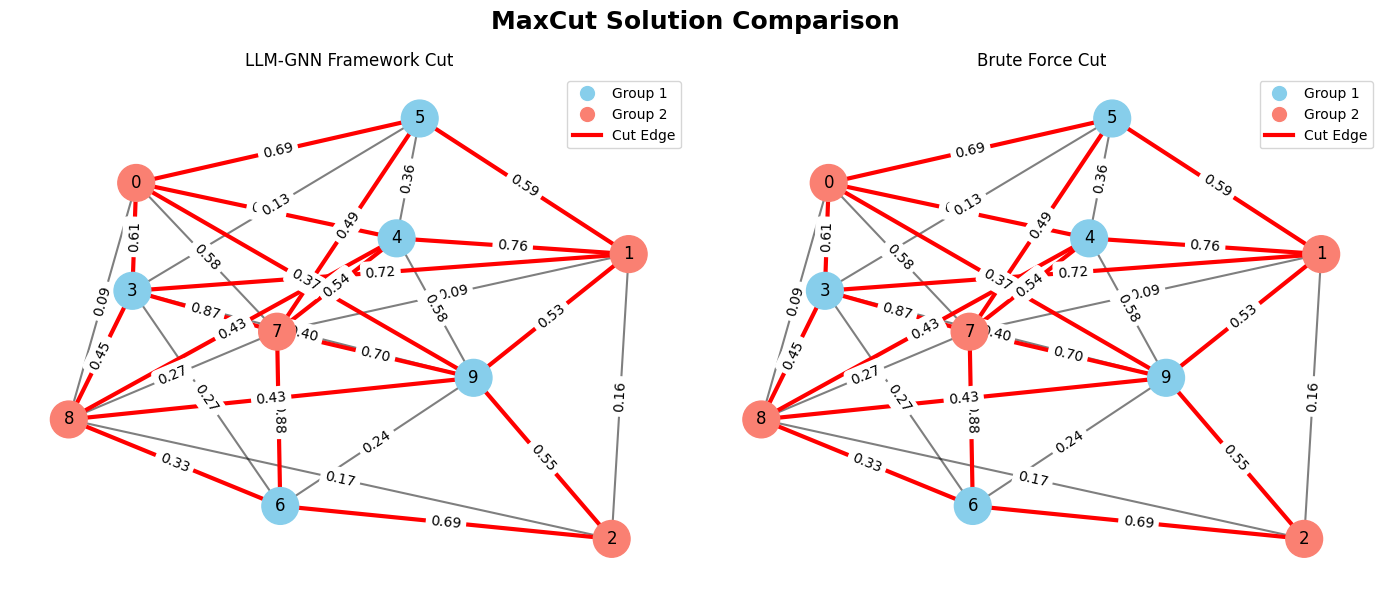

{'adapt_cut': 11.22,
 'optimal_cut': 11.22,
 'optimal_bitstring': [1, 1, 1, 0, 0, 0, 0, 1, 1, 0]}

In [74]:
graph = qaoa_gpt.qaoa_gpt_circ_eval_df[:1]['graph'][0]

bitstring = qaoa_gpt.qaoa_gpt_circ_eval_df[:1]['adapt_gpt_bitstrings'][0][0]

plot_maxcut_compare(
    graph_raw=graph,
    adapt_bitstring= bitstring,
)